# 20 - Derived evidential precision: $\rho_k$ as the dual of carry-over $\lambda_i$

Notebook 19 made an entrenched paradigm *self-censor* the refuting experiment -- but the gate
was **imposed**: a hand-built sigmoid on the held paradigm, masking the three disagreement rows
by fiat. It closed on the honest admission:

> *the gate is imposed, not derived. The active-inference next step is to make experiment choice
> emerge from expected information gain under each agent's own model.*

This notebook takes that step. The move is to see the paradigm as **one precision field over an
augmented graph**. The same hidden core that sets precision on the *internal* edges -- giving the
**carry-over inertia** $\lambda_i$ (how hard a commitment is to revise, the Schur fill-in
$\Pi_{ab}\Pi_{bb}^{-1}\Pi_{ba}$) -- also sets precision on the *sensory* edges, giving the
**evidential gain** $\rho_k$ on each observation channel. "What counts as evidence versus
nuisance" is then not asserted; it is $\lambda_i$ read on the belt's *outward* edges. A channel
whose surprise would force the stiff core to move gets its gain turned **down**. Self-sealing
stops being an assumption and becomes a corollary.

There is one currency here -- **precision** -- and the core governs the most of it, *including the
gain on the very channels that could disconfirm it*.

**Every figure below is also written to `notebooks/figures_nb20/*.png`** (each cell prints the
path), so you can open the plots as image files directly.

In [1]:
import sys, pathlib, dataclasses
ROOT = pathlib.Path.cwd()
sys.path.insert(0, str(ROOT if (ROOT / 'src').exists() else ROOT.parent))

import numpy as np
import matplotlib.pyplot as plt
import jax

from src.structural import phlogiston as ph
from src.structural import step as S
from src.structural import observables as obs
from src.structural import precision as P
from src.structural import agent as A
from src.structural.bmr import carryover
from src.structural.world import sample_o, fisher_deposit, fisher_deposit_weighted
plt.rcParams.update({'figure.dpi': 110, 'axes.grid': True, 'grid.alpha': 0.3})

FIGDIR = (ROOT / 'notebooks' if (ROOT / 'notebooks').exists() else ROOT) / 'figures_nb20'
FIGDIR.mkdir(parents=True, exist_ok=True)
def save(fig, name):
    p = FIGDIR / name
    fig.savefig(p, dpi=130, bbox_inches='tight')
    print('saved figure ->', p.resolve())
    return p

key = jax.random.PRNGKey(0)

# A conviction-bearing PD paradigm. The phlogiston hub couples to eight neighbours at 0.8 with
# self-precision 2.0, so the *bare* prior is indefinite -- the order-parameter solve Pi^{-1}h is
# then ill-posed at weak gain. Raising the self-precisions (base_prec, hub_self_prec) makes the
# common-cause prior positive-definite (2*hub_self_prec > 6.4), which is also what conviction
# *means*: lock-in needs precision AND governance. We bake that conviction into the config so the
# single homogeneous bloc IS the incumbent paradigm.
def paradigm_cfg(g, n_steps=160, mode='derived', **kw):
    return ph.StructuralConfig(
        n_agents=12, n_steps=n_steps, t_shift=40,
        base_prec=5.0, hub_self_prec=10.0, mu_phlog_mass=-1.5,
        precision_mode=mode, core_governance=float(g), **kw)

def m_final(cfg, state):
    fin = S.run_final(cfg, state)
    return float(obs.order_parameter(fin.Pi, fin.h, cfg.node_names,
                 ph.DISAGREEMENT_NODES, cfg.mu_phlog_mass, cfg.mu_oxy_mass))

print('imports OK; figures ->', FIGDIR.resolve())

imports OK; figures -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb20


## 1. The paradigm field and the cost of letting a channel speak

The agent reads each observable commitment through a row of $H$; channel $k$ has an **evidential
precision** $\rho_k$ that scales how hard its prediction error pushes the belief
(`fisher_deposit_weighted` deposits $H^\top\mathrm{diag}(\rho)\,H/\sigma^2$, so $\rho_k$ *is* the
per-channel observation precision). We derive $\rho_k$ from the paradigm's structure.

A surprise on node $v$ would, to be accommodated, drag the hidden core $c$. The structural cost of
that drag is the **carry-over brace** $v$ puts on the core -- the dual of $\lambda_i$, read on the
core:

$$ C_v \;=\; \frac{\Pi[c,v]^2}{\Pi[v,v]} \;=\; \big(\text{carryover}(\,\cdot\,,\{v\})\big)[c,c], \qquad
   \rho_k \;=\; \frac{\rho_{\max}}{1 + g\, C_{v(k)}}, $$

with $g=$ `core_governance` the phase knob ($g{=}0\Rightarrow\rho{=}\rho_{\max}$ everywhere, the
unbiased deposit). One subtlety we must fix honestly: the phlogiston prior asserts a *mean* for the
anomaly `calx_heavier_than_metal` (calx lighter) but leaves it **structurally unbound** -- a
commitment with a mean and no coupling is inert, and the core cannot govern the channel that would
refute it. The `paradigm_field` binds the anomaly into the core web (the prior's stated-but-unbuilt
"weakly attached" anomaly); we return to what happens if it does *not* in §8.

combustion_releases          C_v=0.1280  carryover[core,core]=0.1280
mass_change_sign             C_v=0.1280  carryover[core,core]=0.1280
calx_heavier_than_metal      C_v=0.1280  carryover[core,core]=0.1280


saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb20\01_channel_cost.png


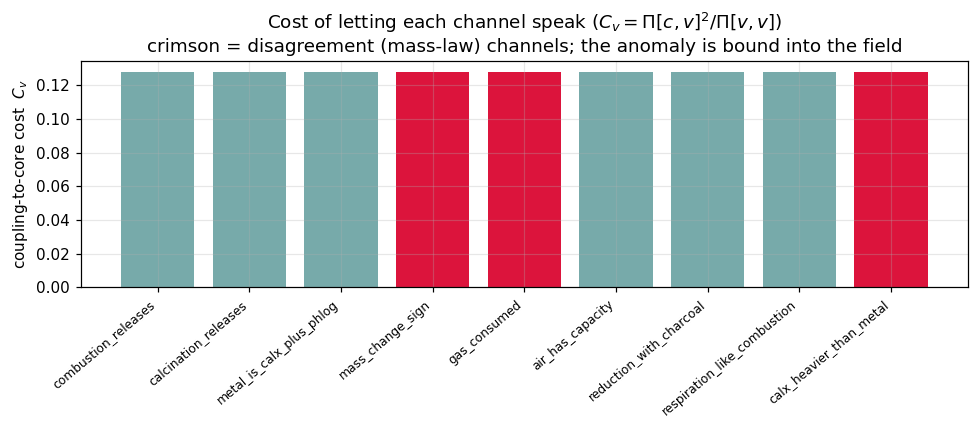


Every hub-bound channel carries the same brace on the core here (a star hub): the three mass-law channels are governed exactly like the agreement ones -- pure structural derivation,
no hand-labelling of "disagreement". Only their *truth* differs (it flips at t_shift).


In [2]:
cfg = paradigm_cfg(0.0)
net = ph.paradigm_field(cfg)                      # the prior with the anomaly bound
meas = list(ph.measured_nodes(cfg))
dis = set(ph.DISAGREEMENT_NODES)
C = np.asarray(P.core_coupling(net, cfg.core_node, tuple(meas), cfg.evidential_cost_kind))

# verify the duality numerically: C_v == carryover fill-in's core-core entry
for n in ['combustion_releases', 'mass_change_sign', 'calx_heavier_than_metal']:
    co = np.asarray(carryover(net, (n,))); surv = tuple(x for x in net.names if x != n)
    ci = surv.index(cfg.core_node); i = meas.index(n)
    print(f'{n:28s} C_v={C[i]:.4f}  carryover[core,core]={co[ci,ci]:.4f}')

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['crimson' if n in dis else '#7aa' for n in meas]
ax.bar(range(len(meas)), C, color=colors)
ax.set_xticks(range(len(meas))); ax.set_xticklabels(meas, rotation=40, ha='right', fontsize=8)
ax.set_ylabel('coupling-to-core cost  $C_v$')
ax.set_title('Cost of letting each channel speak ($C_v=\\Pi[c,v]^2/\\Pi[v,v]$)\n'
             'crimson = disagreement (mass-law) channels; the anomaly is bound into the field')
plt.tight_layout(); save(fig, '01_channel_cost.png'); plt.show()
print('\nEvery hub-bound channel carries the same brace on the core here (a star hub): the three '
      'mass-law channels are governed exactly like the agreement ones -- pure structural derivation,'
      '\nno hand-labelling of "disagreement". Only their *truth* differs (it flips at t_shift).')

## 2. The gain function: how governance silences a channel

$\rho_k = \rho_{\max}/(1+g\,C_{v})$ falls from $\rho_{\max}$ toward $0$ as the core governs more of
the field. The lock-in onset is where $\rho$ on the mass-law channels drops below the level at which
residual Fisher accumulated over the horizon can still cross the threshold (here, with $C_v\approx
0.13$, around $g\sim10^2$-$10^3$).

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb20\02_gain_function.png


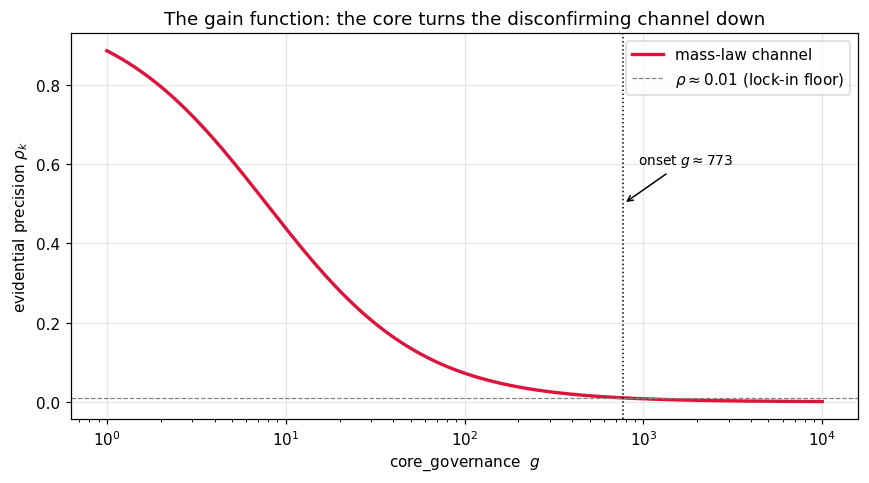

In [3]:
gs = np.logspace(0, 4, 200)
Cmass = float(C[meas.index('mass_change_sign')])
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogx(gs, 1.0/(1.0 + gs*Cmass), color='crimson', lw=2.2, label='mass-law channel')
ax.axhline(0.01, color='grey', ls='--', lw=0.8, label=r'$\rho\approx0.01$ (lock-in floor)')
g_floor = (1/0.01 - 1)/Cmass
ax.axvline(g_floor, color='k', ls=':', lw=1)
ax.annotate(f'onset $g\\approx{g_floor:.0f}$', (g_floor, 0.5), fontsize=9,
            xytext=(g_floor*1.2, 0.6), arrowprops=dict(arrowstyle='->'))
ax.set_xlabel('core_governance  $g$'); ax.set_ylabel(r'evidential precision $\rho_k$')
ax.set_title('The gain function: the core turns the disconfirming channel down'); ax.legend()
plt.tight_layout(); save(fig, '02_gain_function.png'); plt.show()

## 3. One core, two edges: $\lambda$ (internal inertia) and $\rho$ (sensory gain)

The same Schur fill-in read two ways. **Left:** $\lambda_v=\lVert\text{carryover}(\cdot,\{v\})\rVert_F$
-- the internal inertia, how much each node braces the net. The hidden hub dominates: it is the
core, maximally entrenched against revision. **Right:** the derived $\rho_k$ on each *channel* at a
fixed governance -- the sensory gain, turned down on exactly the channels the core binds. The core
that is hardest to revise from the inside is the one that quietest the world from the outside.

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb20\03_lambda_rho_duality.png


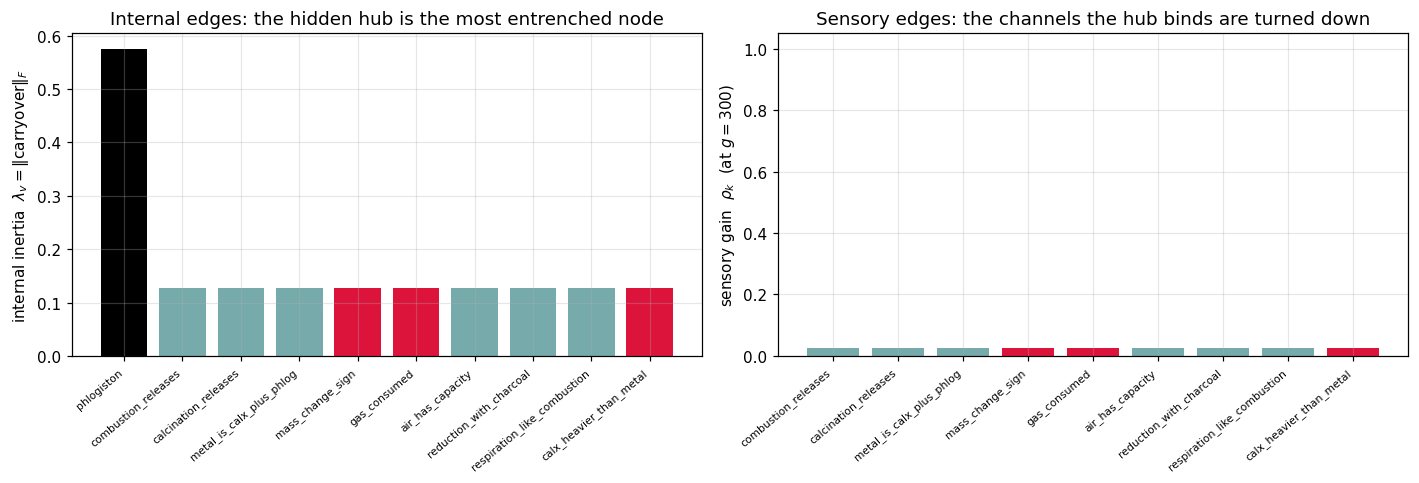

hub internal inertia lambda_hub = 0.58  (vs leaf nodes ~ 0.13): the core carries the field.


In [4]:
all_nodes = list(cfg.node_names)
lam = np.array([obs.carryover_mass(net, (n,)) for n in all_nodes])
rho_g = np.asarray(ph.derived_channel_precision(paradigm_cfg(300.0)))

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.5))
colL = ['k' if n == ph.HUB else ('crimson' if n in dis else '#7aa') for n in all_nodes]
axL.bar(range(len(all_nodes)), lam, color=colL)
axL.set_xticks(range(len(all_nodes))); axL.set_xticklabels(all_nodes, rotation=40, ha='right', fontsize=7)
axL.set_ylabel(r'internal inertia  $\lambda_v=\Vert$carryover$\Vert_F$')
axL.set_title('Internal edges: the hidden hub is the most entrenched node')
colR = ['crimson' if n in dis else '#7aa' for n in meas]
axR.bar(range(len(meas)), rho_g, color=colR)
axR.set_xticks(range(len(meas))); axR.set_xticklabels(meas, rotation=40, ha='right', fontsize=7)
axR.set_ylabel(r'sensory gain  $\rho_k$  (at $g=300$)'); axR.set_ylim(0, 1.05)
axR.set_title('Sensory edges: the channels the hub binds are turned down')
plt.tight_layout(); save(fig, '03_lambda_rho_duality.png'); plt.show()
print(f'hub internal inertia lambda_hub = {lam[all_nodes.index(ph.HUB)]:.2f}  '
      f'(vs leaf nodes ~ {np.median(lam[lam>0][1:]):.2f}): the core carries the field.')

## 4. Single-bloc lock-in (the headline)

A single homogeneous paradigm, run through the regime flip at several governance levels. At $g=0$
the bloc reorganises and crosses $\tfrac12$ to oxygen -- **graded reorganization**. As $g$ rises the
disconfirming channels are silenced and $m(t)$ stalls below $\tfrac12$ despite the refuting data
being physically present every step -- **evidential lock-in**. The lower panel shows the derived
$\rho$ on the mass-law channels (flat in $t$: it is a paradigm-level constant, *not* a response to
the agent's stance -- the structural difference from notebook 19's gate).

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb20\04_single_bloc_lockin.png


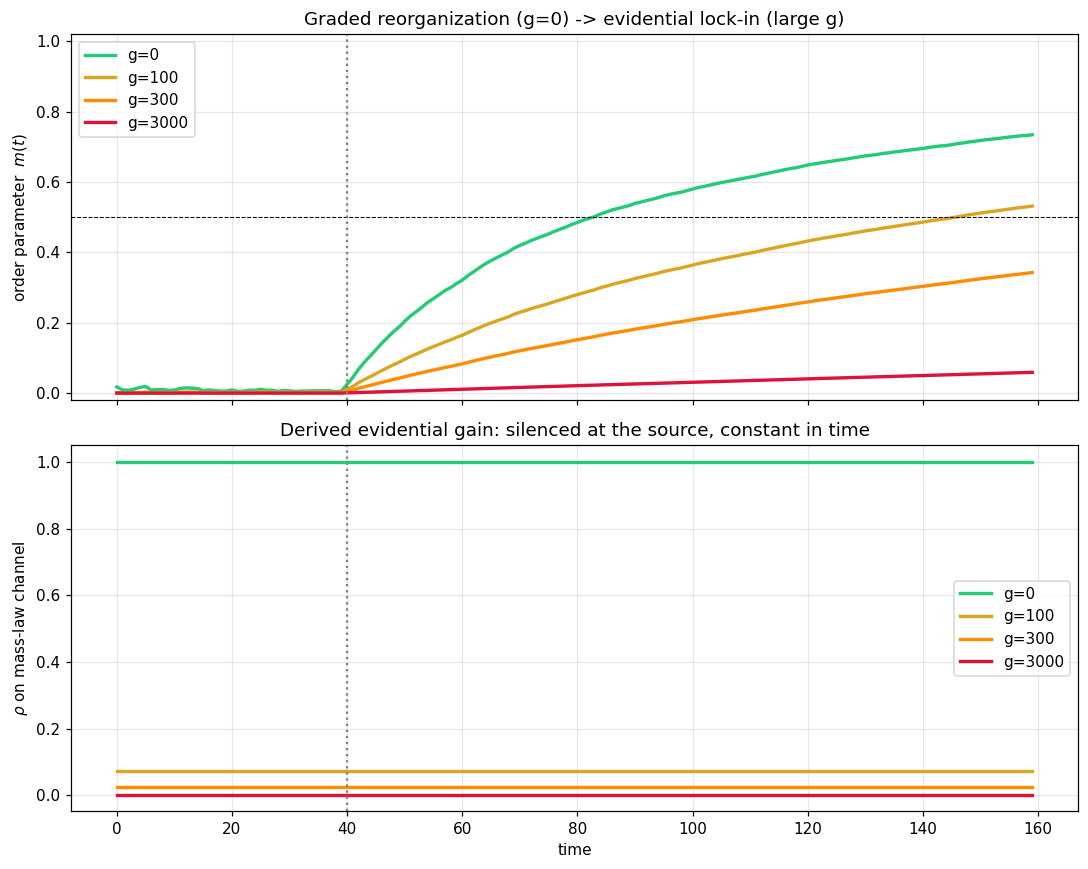

In [5]:
G_LIST = [(0.0, '#2c7'), (100.0, 'goldenrod'), (300.0, 'darkorange'), (3000.0, 'crimson')]
fig, (axA, axB) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
for g, col in G_LIST:
    cfg_g = paradigm_cfg(g)
    ms, gw, rho_dis = S.run_trace_precision(cfg_g, S.init_state(cfg_g, key))
    axA.plot(np.asarray(ms), color=col, lw=2.2, label=f'g={g:.0f}')
    axB.plot(np.asarray(rho_dis)[:, 0], color=col, lw=2.2, label=f'g={g:.0f}')
axA.axhline(0.5, color='k', ls='--', lw=0.7); axA.axvline(40, color='grey', ls=':')
axA.set_ylabel('order parameter  $m(t)$'); axA.set_ylim(-0.02, 1.02)
axA.set_title('Graded reorganization (g=0) -> evidential lock-in (large g)'); axA.legend()
axB.axvline(40, color='grey', ls=':')
axB.set_xlabel('time'); axB.set_ylabel(r'$\rho$ on mass-law channel')
axB.set_title('Derived evidential gain: silenced at the source, constant in time'); axB.legend()
plt.tight_layout(); save(fig, '04_single_bloc_lockin.png'); plt.show()

## 5. The phase boundary: $m(\infty)$ as a function of how much the core governs

Sweep $g$ and read $m$ at the horizon. The transition from graded reorganization ($m>\tfrac12$) to
evidential lock-in ($m<\tfrac12$) is continuous in $g$ -- the precision-field analogue of notebook
19's bias$\times$conviction diagram, but now the knob is **derived**: it is literally how much of the
sensory precision field the core governs. (Honest scope: with no forgetting the substrate is a
ratchet, so "locked" means residual $\rho\cdot T \ll$ prior mass precision over this horizon -- a
graded transition, not a second basin.)

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb20\05_phase_boundary.png


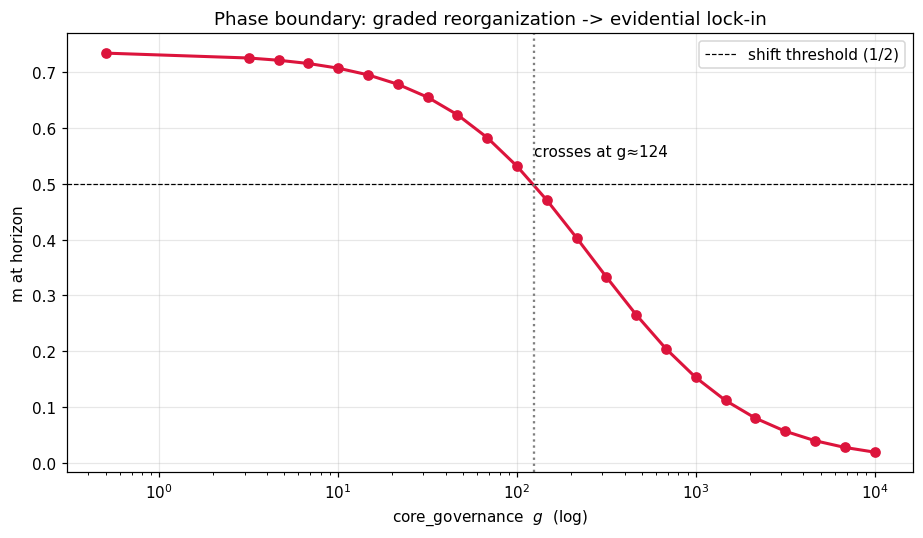

graded (g=0): m=0.734   locked (g=10000): m=0.019


In [6]:
g_sweep = np.concatenate([[0.0], np.logspace(0.5, 4, 22)])
m_sweep = np.array([m_final(paradigm_cfg(g), S.init_state(paradigm_cfg(g), key)) for g in g_sweep])
fig, ax = plt.subplots(figsize=(8.5, 5))
ax.semilogx(np.clip(g_sweep, 0.5, None), m_sweep, 'o-', color='crimson', lw=2)
ax.axhline(0.5, color='k', ls='--', lw=0.8, label='shift threshold (1/2)')
gc = np.clip(g_sweep, 0.5, None)
cross = np.interp(0.5, m_sweep[::-1], gc[::-1])
ax.axvline(cross, color='grey', ls=':'); ax.annotate(f'crosses at g≈{cross:.0f}', (cross, 0.55))
ax.set_xlabel('core_governance  $g$  (log)'); ax.set_ylabel('m at horizon')
ax.set_title('Phase boundary: graded reorganization -> evidential lock-in'); ax.legend()
plt.tight_layout(); save(fig, '05_phase_boundary.png'); plt.show()
print(f'graded (g=0): m={m_sweep[0]:.3f}   locked (g={g_sweep[-1]:.0f}): m={m_sweep[-1]:.3f}')

## 6. Two biases at model selection: additive value vs multiplicative evidence

The motivated agent's verdict carries two distinct biases.

- **Additive value bias** ($-\Delta U$): a preference over *topology*, a constant offset to the
  log-evidence favouring the incumbent. This is the existing BMR $\Delta F$ -- scoring under a
  value-tilted posterior. (Left.)
- **Multiplicative evidential bias**: the Bayes factor is computed under the **incumbent's own**
  $R(G)=\mathrm{diag}(\rho_k)$. The rival's characteristic anomaly arrives on a channel the
  incumbent has parked at $\rho\approx0$, so its contribution to the log Bayes factor is attenuated
  *at the source*. (Right.) Both candidates share the *same* weighted Fisher, so the gap difference
  is purely $R$ -- the agent weighs the evidence for leaving the incumbent using the incumbent's
  precision metric, and a paradigm-neutral arbiter's common $R$ is exactly what it has no access to.

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb20\06_two_biases.png


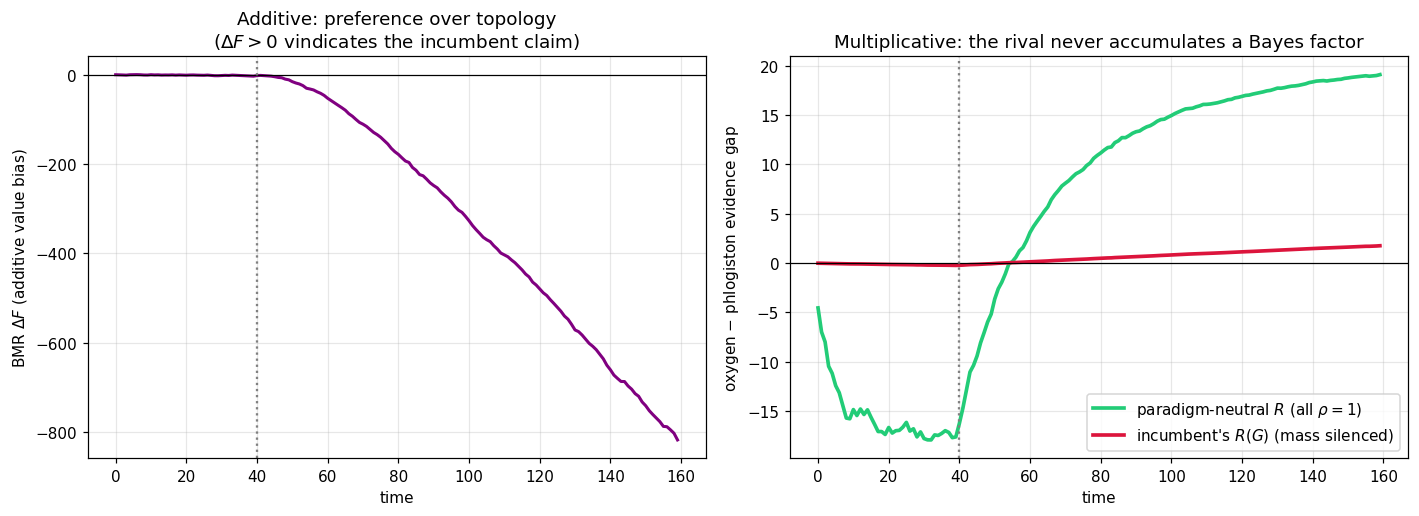

gap growth after the flip:  neutral R = +35.4   incumbent R(G) = +2.0


In [7]:
cfg_b = ph.StructuralConfig(n_steps=160, t_shift=40, base_prec=5.0, hub_self_prec=10.0,
                            mu_phlog_mass=-1.5, precision_mode='derived', core_governance=3000.0)
H = ph.H_observable(cfg_b)
rr = A.evidence_race(cfg_b, key)                                   # for the additive Delta F
gap_neutral   = np.asarray(A.evidence_race_weighted(cfg_b, key, jax.numpy.ones(H.shape[0]))['gap'])
gap_incumbent = np.asarray(A.evidence_race_weighted(cfg_b, key, ph.derived_channel_precision(cfg_b))['gap'])

fig, (axL, axR) = plt.subplots(1, 2, figsize=(13, 4.8))
axL.plot(np.asarray(rr['delta_F']), color='purple', lw=2)
axL.axhline(0, color='k', lw=0.8); axL.axvline(40, color='grey', ls=':')
axL.set_xlabel('time'); axL.set_ylabel(r'BMR $\Delta F$ (additive value bias)')
axL.set_title('Additive: preference over topology\n($\\Delta F>0$ vindicates the incumbent claim)')
axR.plot(gap_neutral, color='#2c7', lw=2.4, label='paradigm-neutral $R$ (all $\\rho=1$)')
axR.plot(gap_incumbent, color='crimson', lw=2.4, label="incumbent's $R(G)$ (mass silenced)")
axR.axhline(0, color='k', lw=0.8); axR.axvline(40, color='grey', ls=':')
axR.set_xlabel('time'); axR.set_ylabel('oxygen $-$ phlogiston evidence gap')
axR.set_title('Multiplicative: the rival never accumulates a Bayes factor'); axR.legend()
plt.tight_layout(); save(fig, '06_two_biases.png'); plt.show()
ts = cfg_b.t_shift
print(f'gap growth after the flip:  neutral R = {gap_neutral[-1]-gap_neutral[ts]:+.1f}   '
      f'incumbent R(G) = {gap_incumbent[-1]-gap_incumbent[ts]:+.1f}')

## 7. Bubble versus echo chamber: access failure versus governance failure

The precision reading gives a crisp, physical distinction the literature usually leaves mushy.

- A **bubble** is a *missing edge*: the disconfirming channel is physically absent (its rows are not
  in $H$). No data arrive. **Restoring the channel pops the bubble** -- information flows immediately.
- An **echo chamber** is a *live edge with the gain off*: the channel is present and sampled every
  step, but $\rho\approx0$. The data arrive and are deposited with $\approx0$ precision.
  **Re-showing the same data does nothing**; only turning the gain back up (a governance change)
  moves it.

Same world, same seed, same incoming data. The distinguishing scalar is the cumulative Fisher
deposited on the mass nodes: zero-then-jump for the bubble (restored at $t{=}50$), flat-at-zero for
the chamber even though it has been "seeing" the data all along.

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb20\07_bubble_vs_chamber.png


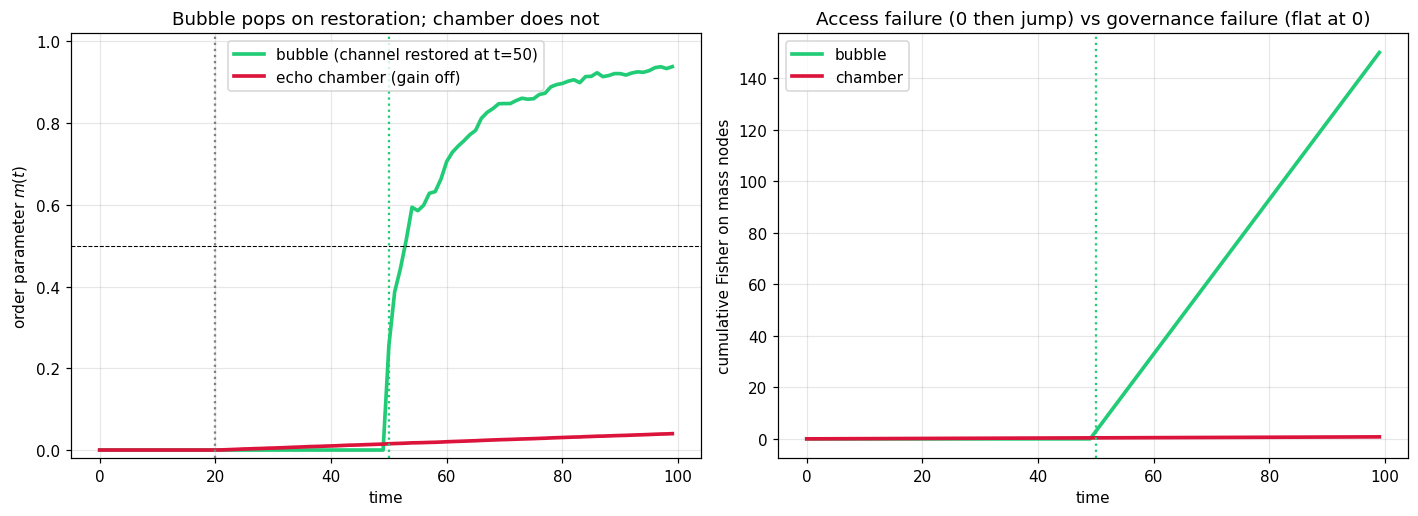

A bubble is fixed by connecting the channel; an echo chamber is not -- the channel is connected, the paradigm refuses to weight it. Same data, different repair.


In [8]:
cfg_c = ph.StructuralConfig(n_steps=100, t_shift=20, base_prec=5.0, hub_self_prec=10.0,
                            mu_phlog_mass=-1.5)
Hn = np.asarray(ph.H_observable(cfg_c)); meas_c = list(ph.measured_nodes(cfg_c))
dis_rows = [meas_c.index(n) for n in ph.DISAGREEMENT_NODES]
mass_cols = [cfg_c.node_names.index(n) for n in ph.DISAGREEMENT_NODES]
rho_chamber = np.asarray(ph.derived_channel_precision(
    dataclasses.replace(cfg_c, precision_mode='derived', core_governance=3000.0)))
t_restore = 50

def run_world(mode):
    # mode: 'bubble' (rows absent, restored at t_restore) | 'chamber' (rows present, rho~0)
    prior = ph.phlogiston_prior(cfg_c)
    Pi = np.asarray(prior.Pi).copy(); h = np.asarray(prior.h).copy(); k = key
    ms, cumF, run = [], [], 0.0
    for t in range(cfg_c.n_steps):
        phi = ph.phi_true_at(cfg_c, t); k, sub = jax.random.split(k)
        if mode == 'bubble':
            Huse = Hn.copy()
            if t < t_restore:
                Huse[dis_rows] = 0.0                       # channel absent until restored
            o = sample_o(jax.numpy.asarray(Huse), phi, cfg_c.sigma_o, sub)
            J, j = fisher_deposit(jax.numpy.asarray(Huse), o, cfg_c.sigma_o)
        else:  # chamber: channel always present, gain off
            o = sample_o(jax.numpy.asarray(Hn), phi, cfg_c.sigma_o, sub)
            J, j = fisher_deposit_weighted(jax.numpy.asarray(Hn), o, cfg_c.sigma_o,
                                           jax.numpy.asarray(rho_chamber))
        J = np.asarray(J); Pi = Pi + J; h = h + np.asarray(j)
        run += float(np.sum(np.diag(J)[mass_cols]))
        mu = np.linalg.solve(Pi, h)
        frac = np.clip((mu[mass_cols].mean() - cfg_c.mu_phlog_mass)
                       / (cfg_c.mu_oxy_mass - cfg_c.mu_phlog_mass), 0, 1)
        ms.append(float(frac)); cumF.append(run)
    return np.array(ms), np.array(cumF)

mb, fb = run_world('bubble'); mc, fc = run_world('chamber')
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.8))
axA.plot(mb, color='#2c7', lw=2.4, label='bubble (channel restored at t=50)')
axA.plot(mc, color='crimson', lw=2.4, label='echo chamber (gain off)')
axA.axhline(0.5, color='k', ls='--', lw=0.7); axA.axvline(20, color='grey', ls=':')
axA.axvline(t_restore, color='#2c7', ls=':'); axA.set_ylim(-0.02, 1.02)
axA.set_xlabel('time'); axA.set_ylabel('order parameter $m(t)$')
axA.set_title('Bubble pops on restoration; chamber does not'); axA.legend()
axB.plot(fb, color='#2c7', lw=2.4, label='bubble'); axB.plot(fc, color='crimson', lw=2.4, label='chamber')
axB.axvline(t_restore, color='#2c7', ls=':')
axB.set_xlabel('time'); axB.set_ylabel('cumulative Fisher on mass nodes')
axB.set_title('Access failure (0 then jump) vs governance failure (flat at 0)'); axB.legend()
plt.tight_layout(); save(fig, '07_bubble_vs_chamber.png'); plt.show()
print('A bubble is fixed by connecting the channel; an echo chamber is not -- the channel is '
      'connected, the paradigm refuses to weight it. Same data, different repair.')

## 8. Why the paradigm must bind its anomaly (self-sealing is structural)

The derivation governs only what the core *binds*. If the paradigm leaves its anomaly
(`calx_heavier_than_metal`) structurally unbound -- a mean with no coupling -- then that channel
stays at full gain and the rival leaks straight through it: the seal is **incomplete**. Binding the
anomaly into the core web (the prior's stated-but-unbuilt "weakly attached") completes the seal.
Self-sealing is thus not a free lunch; it is a property of how much of the world the core has
actually woven into itself.

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb20\08_anomaly_binding.png


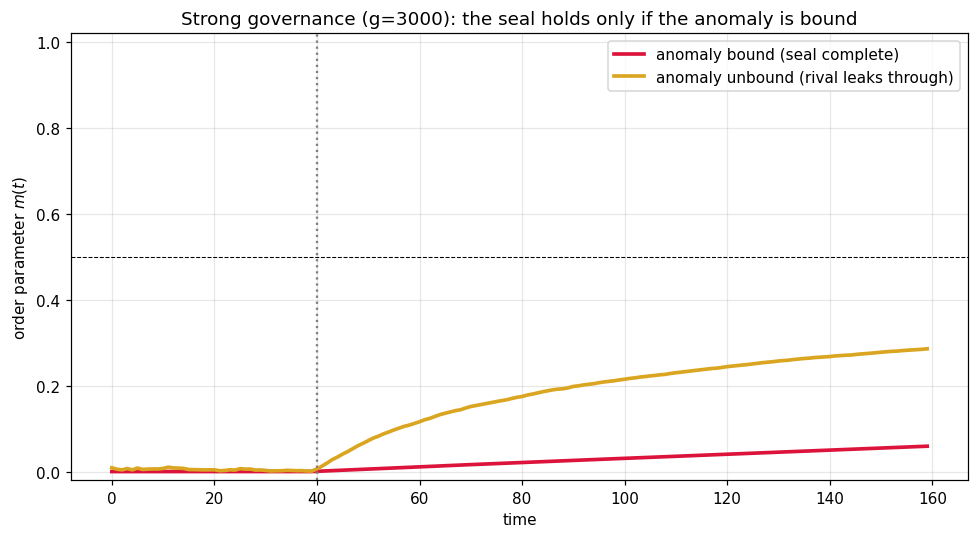

In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
for anom, col, lab in [(None, 'crimson', 'anomaly bound (seal complete)'),
                       (0.0, 'goldenrod', 'anomaly unbound (rival leaks through)')]:
    cfg_g = paradigm_cfg(3000.0, anomaly_coupling=anom)
    ms = np.asarray(S.run_trace_precision(cfg_g, S.init_state(cfg_g, key))[0])
    ax.plot(ms, color=col, lw=2.4, label=lab)
ax.axhline(0.5, color='k', ls='--', lw=0.7); ax.axvline(40, color='grey', ls=':')
ax.set_xlabel('time'); ax.set_ylabel('order parameter $m(t)$'); ax.set_ylim(-0.02, 1.02)
ax.set_title('Strong governance (g=3000): the seal holds only if the anomaly is bound'); ax.legend()
plt.tight_layout(); save(fig, '08_anomaly_binding.png'); plt.show()

## 9. At population scale (fusion holds the field)

The mechanism survives fusion: a governed paradigm, spread over a trust network of 60 agents, locks
the whole population below the threshold, where the same population at $g=0$ reorganises. (Because
the derived $\rho$ is a paradigm-level constant, a population *sharing* the paradigm locks in
together; a genuinely mixed population needs per-school governance -- the structural twin of the
notebook-19 capture, and the natural next extension. The Discussion's external curator on the trust
channels $\pi_s$ is the same operation on a different edge class: the core gates $\rho$ on sensory
channels, the curator gates $\pi_s$ on trust channels.)

saved figure -> C:\GitHub\Paradigm_Shift_Act_Inf\notebooks\figures_nb20\09_population.png


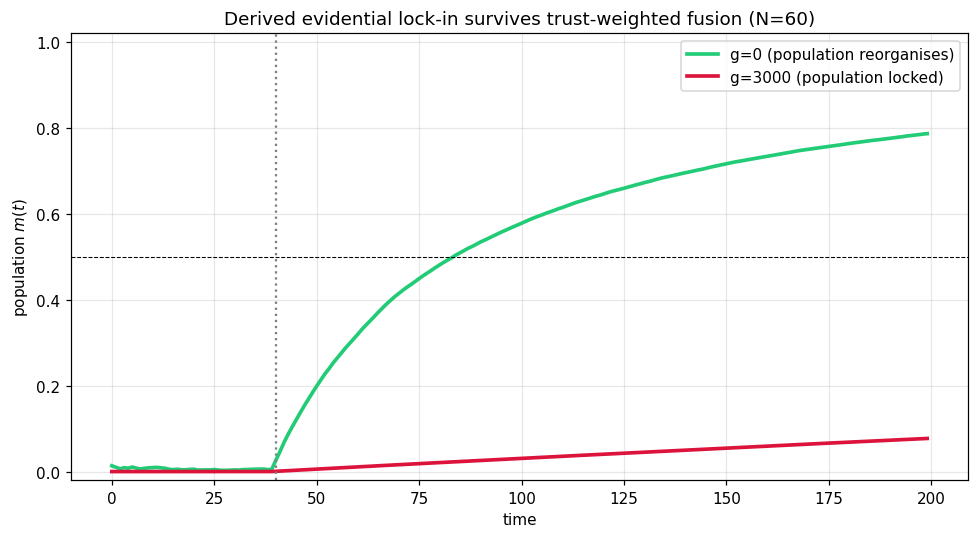

In [10]:
fig, ax = plt.subplots(figsize=(9, 5))
for g, col, lab in [(0.0, '#2c7', 'g=0 (population reorganises)'),
                    (3000.0, 'crimson', 'g=3000 (population locked)')]:
    cfg_p = ph.StructuralConfig(n_agents=60, n_steps=200, t_shift=40, base_prec=5.0,
                                hub_self_prec=10.0, mu_phlog_mass=-1.5,
                                precision_mode='derived', core_governance=g)
    ms = np.asarray(S.run_trace_precision(cfg_p, S.init_state(cfg_p, key))[0])
    ax.plot(ms, color=col, lw=2.4, label=lab)
ax.axhline(0.5, color='k', ls='--', lw=0.7); ax.axvline(40, color='grey', ls=':')
ax.set_xlabel('time'); ax.set_ylabel('population $m(t)$'); ax.set_ylim(-0.02, 1.02)
ax.set_title('Derived evidential lock-in survives trust-weighted fusion (N=60)'); ax.legend()
plt.tight_layout(); save(fig, '09_population.png'); plt.show()

## 10. Summary

- **$\rho_k$ is the expected-free-energy precision allocation pointed outward** -- the exact dual of
  the carry-over inertia $\lambda_i$. Both are the same Schur fill-in of the paradigm's precision
  field: $\lambda$ read on the internal edges (resistance to revision), $\rho$ read on the sensory
  edges (gain on the world). The core that is hardest to revise is the one that quietest the
  channels that would revise it -- *self-sealing is a corollary, not an assumption.* This answers
  notebook 19's open question: the gate is now **derived**, not imposed.
- **`core_governance` $g$ is the phase-transition knob**: graded reorganization below, evidential
  lock-in above (basin $\sim O(10^2$-$10^3)$, scaled by conviction; horizon-bounded without
  forgetting). It is the sensory-edge analogue of `prec_scale`.
- **Two biases are distinct and composable**: the *additive* value bias ($-\Delta U$, a preference
  over topology) and the *multiplicative* evidential bias (the Bayes factor read under the
  incumbent's own $R(G)$, so the rival's anomaly never accumulates). The agent weighs the evidence
  for leaving using the incumbent's precision metric -- which is why the bias is invisible from
  inside.
- **Bubble $\neq$ echo chamber**: a missing edge (access failure, fixed by connecting the channel)
  versus a live edge with the gain off (governance failure, *not* fixed by more data). The precision
  reading makes the distinction physical and measurable.
- **Self-sealing is structural** (§8): the core governs only what it binds; an unbound anomaly leaks.
- All figures are under `notebooks/figures_nb20/`.